00 Data Exploration

- First look at the raw 16-bit Airyscan stacks.
- Fine image dimensions, per-channel signal quality, autofluorescence distribution
- used for the baseline comparison

In [53]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from src.io import load_stack
from src.preprocess import normalize_for_segmentation

In [ ]:
PROJECT_ROOT  = Path('/Users/alicehong/projects/cellpose-biosensor')
STACK_PATH    = PROJECT_ROOT / 'data/raw/16bit/Scene-04-20260416-C3M2_Tcol_3-A01Export-06_c1-4_stack.tif'
FIG_DIR       = PROJECT_ROOT / 'figures/qc'
PIXEL_SIZE_UM = 0.035   # um/px (found from Zen Image Properties!)

FIG_DIR.mkdir(parents=True, exist_ok=True)

Load and verify stack

In [55]:
stack = load_stack(STACK_PATH)
print(f'Shape : {stack.shape}')
print(f'Dtype : {stack.dtype}')
print(f'Global max: {stack.max()}')
print(f'Image size: {stack.shape[1]*PIXEL_SIZE_UM:.1f} × {stack.shape[2]*PIXEL_SIZE_UM:.1f} µm')

Shape : (4, 6382, 6397)
Dtype : uint16
Global max: 7360
Image size: 223.4 × 223.9 µm


Per-channel intensity statistics

- Raw uint16 values BFP is the segmentation channel (C1), GFP and RFP are stress reporters, SYTOX labels nucelic acid

In [56]:
CHANNELS = ['BFP (C1)', 'GFP (C2)', 'RFP (C3)', 'SYTOX (C4)']

print(f"{'Channel':<14} {'Min':>7} {'Max':>7} {'Mean':>8} {'Std':>8} {'p1':>7} {'p99':>8}")
print('-' * 65)
for i, name in enumerate(CHANNELS):
    ch = stack[i].astype(float)
    p1, p99 = np.percentile(ch, [1, 99])
    print(f'{name:<14} {ch.min():>7.0f} {ch.max():>7.0f} '
          f'{ch.mean():>8.1f} {ch.std():>8.1f} {p1:>7.0f} {p99:>8.0f}')

Channel            Min     Max     Mean      Std      p1      p99
-----------------------------------------------------------------
BFP (C1)             0    4714    140.6    198.6       0      983
GFP (C2)             0    3500      8.2     40.0       0      139
RFP (C3)             0    1313      7.0     33.1       0      150
SYTOX (C4)           0    7360    200.9    417.0       0     2110


4-channel visualisation

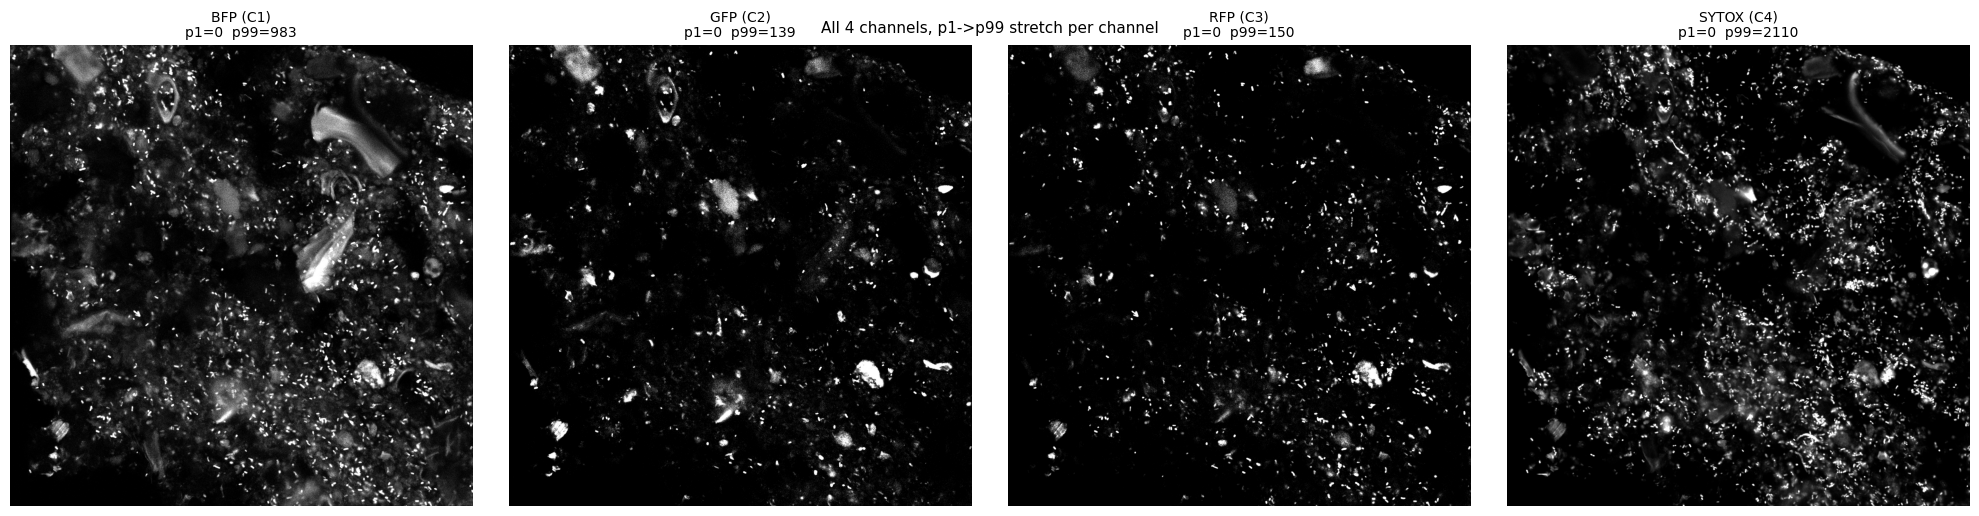

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), facecolor='white')

for i, (ax, name, cmap) in enumerate(zip(axes, CHANNELS, cmaps)):
    ch  = stack[i].astype(np.float32)
    lo  = float(np.percentile(ch, 1))
    hi  = float(np.percentile(ch, 99))  # 99 so rare autofl blobs don't compress the range
    img_norm = np.clip((ch - lo) / (hi - lo), 0, 1)
    ax.imshow(img_norm, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'{name}\np1={lo:.0f}  p99={hi:.0f}', color='black', fontsize=10)
    ax.axis('off')

fig.suptitle('All 4 channels, p1->p99 stretch per channel', color='black', fontsize=11)
plt.tight_layout(pad=0.3)

# Uncomment to save figure!
#plt.savefig(FIG_DIR / '00_four_channels.svg', dpi=100, bbox_inches='tight', facecolor='white')
plt.show()

intensity histograms

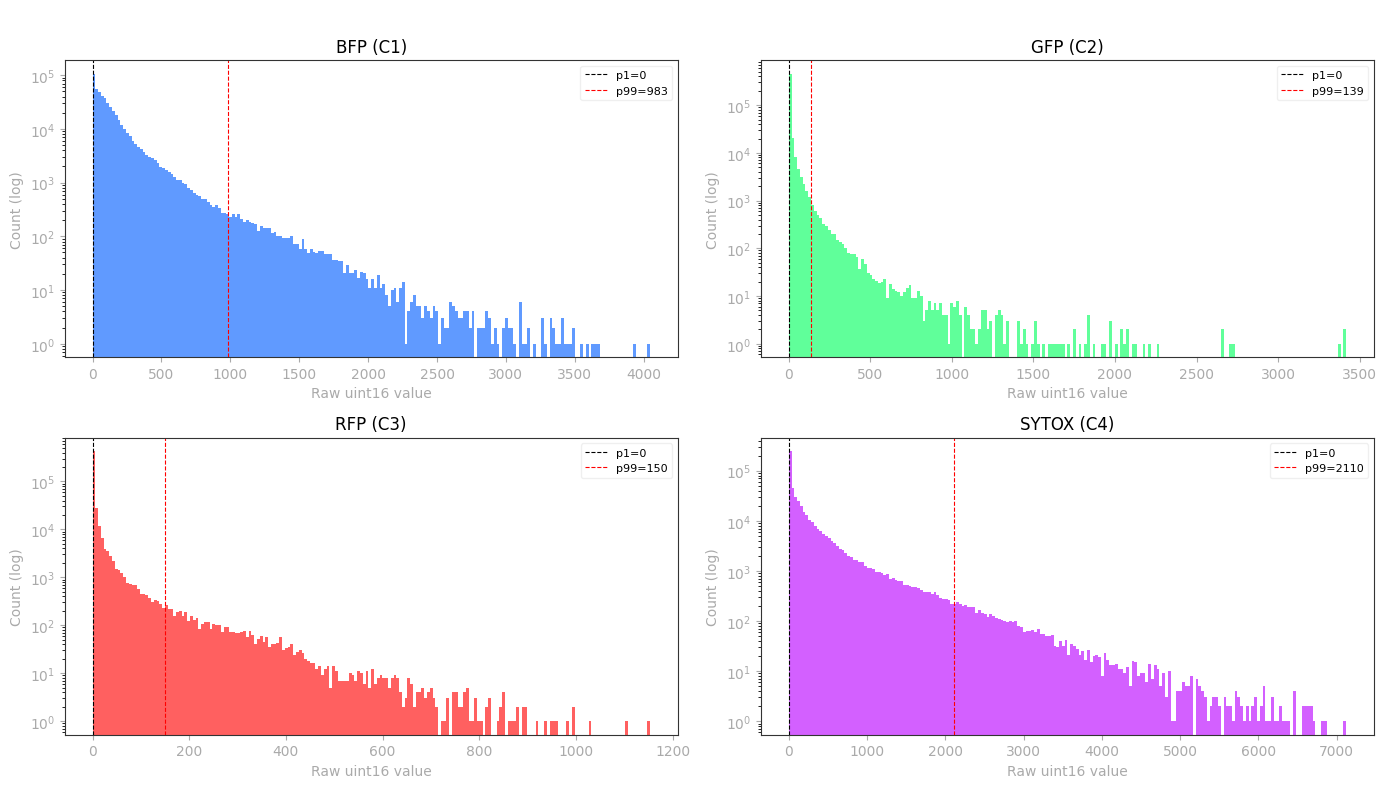

In [65]:
# Subsample to speed up histogram computation
rng = np.random.default_rng(42)
idx = rng.integers(0, H * W, size=500_000)
rows, cols = np.unravel_index(idx, (H, W))

fig, axes = plt.subplots(2, 2, figsize=(14, 8), facecolor='white')
colors = ['#4488ff', '#44ff88', '#ff4444', '#cc44ff']

for i, (ax, name, color) in enumerate(zip(axes.flat, CHANNELS, colors)):
    ax.set_facecolor('white')
    vals = stack[i][rows, cols].astype(float)
    ax.hist(vals, bins=200, color=color, alpha=0.85, log=True)
    p1, p99 = np.percentile(stack[i], [1, 99])
    ax.axvline(p1,  color='black', lw=0.8, ls='--', label=f'p1={p1:.0f}')
    ax.axvline(p99, color='red', lw=0.8, ls='--', label=f'p99={p99:.0f}')
    ax.set_title(name, color='black')
    ax.set_xlabel('Raw uint16 value', color='#aaa')
    ax.set_ylabel('Count (log)', color='#aaa')
    ax.tick_params(colors='#aaa')
    ax.legend(fontsize=8, labelcolor='black', framealpha=0.3)
    for sp in ax.spines.values(): sp.set_edgecolor('#333')

fig.suptitle('Per-channel intensity histograms (500k pixel subsample, log y)',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / '00_channel_histograms.svg', dpi=100,
            bbox_inches='tight', facecolor='white')
plt.show()

correlations between channels

- autofluorescent fecal debris should shows high GFP and RFP simultaneously relative to BFP.
- bacteria should show BFP-high, GFP/RFP variable (biological state dependent).

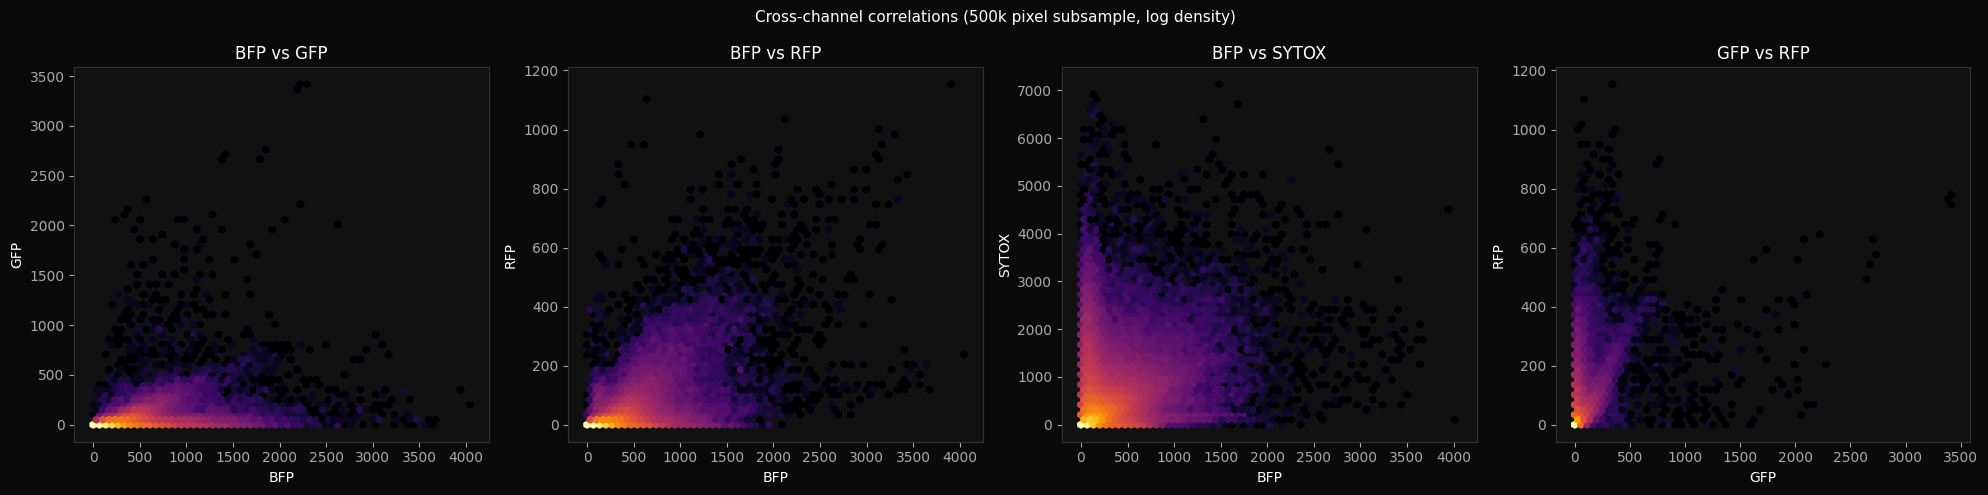

In [ ]:
bfp_s = stack[0][rows, cols].astype(float)
gfp_s = stack[1][rows, cols].astype(float)
rfp_s = stack[2][rows, cols].astype(float)
syt_s = stack[3][rows, cols].astype(float)

pairs = [
    (bfp_s, gfp_s, 'BFP', 'GFP', '#44ff88'),
    (bfp_s, rfp_s, 'BFP', 'RFP', '#ff4444'),
    (bfp_s, syt_s, 'BFP', 'SYTOX', '#cc44ff'),
    (gfp_s, rfp_s, 'GFP', 'RFP', '#ffcc44'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), facecolor='#0a0a0a')
for ax, (x, y, xn, yn, col) in zip(axes, pairs):
    ax.set_facecolor('#111')
    ax.hexbin(x, y, gridsize=60, cmap='inferno', bins='log', mincnt=1)
    ax.set_xlabel(xn, color='white')
    ax.set_ylabel(yn, color='white')
    ax.set_title(f'{xn} vs {yn}', color='white')
    ax.tick_params(colors='#aaa')
    for sp in ax.spines.values(): sp.set_edgecolor('#333')

fig.suptitle('Cross-channel correlations (500k pixel subsample, log density)',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / '00_cross_correlations.png', dpi=100,
            bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

Notes

Image size: (4, 6323, 6344) uint16 

Pixel size: 0.035 µm/px (from Zen)

Field of view: ~221 × 222 µm 

BFP dynamic range: p1=0, p99=734, p99.9=~1700 

Autofluorescence: High min(GFP,RFP)/BFP, see cross-correlations and spectral filter 

Normalization notes:
- Global p99 for reporter channels (GFP p99=90, RFP p99=114) is very low, normalising each channel to its own p99 exaggerates faint signal and gives a false impression that reporters are expressed everywhere.
- The 4-channel overview uses p99.9 per channel to show more of the real dynamic range.
- The crop preview shows all channels on the BFP scale 